# 01 — Exploratory Data Analysis: Austin Animal Shelter (Dogs & Cats)

**Goal:** understand what predicts **adoption** (`is_adopted`) for shelter animals, as preparation for a later modeling step. This notebook is **EDA only** — no cleaning, no feature engineering for a model, no training.

**Why dogs and cats are analyzed *separately, side by side* in every section (never pooled):**
1. Dog adopters and cat adopters are **different populations**.
2. **Breed distributions don't overlap** — cats are dominated by *Domestic Shorthair*; dogs spread across *Pit Bull, Labrador, Chihuahua, German Shepherd, ...*
3. **Age pushes the two species in opposite directions** (senior cats get adopted *more*, senior dogs *less*). A single pooled chart/model would average away these opposite signals.

The dataset is already cleaned and pre-merged (one row per outcome event, each outcome joined to its intake record). **We do not re-clean anything here.**

## 1. Setup & Load

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Consistent species colors used everywhere in this notebook
DOG_COLOR = 'steelblue'
CAT_COLOR = 'darkorange'

In [ ]:
DATA_PATH = '../data/processed/df_full_merged.csv'

df = pd.read_csv(DATA_PATH)


df['animal_type'].value_counts(dropna=False)

Loaded df_raw: (162765, 21)
Derived intake_year / intake_month / intake_dayofweek from intake_date.


animal_type
Dog    93962
Cat    68803
Name: count, dtype: int64

### 1.1 Leakage columns — listed so we never use them as features
These are known only **after** the animal leaves the shelter, so they cannot predict adoption. `length_of_stay_days` is the target of a *separate* problem, not a feature here.

In [198]:
# For reference only — never feed these to a model.
LEAKAGE_COLS = [
    'outcome_type', 'outcome_subtype', 'outcome_date',
    'length_of_stay_days', 'is_RTO', 'is_transfer', 'is_euthanasia',
]
TARGET = 'is_adopted'
print('Leakage (excluded from features):', LEAKAGE_COLS)
print('Target:', TARGET)

Leakage (excluded from features): ['outcome_type', 'outcome_subtype', 'outcome_date', 'length_of_stay_days', 'is_RTO', 'is_transfer', 'is_euthanasia']
Target: is_adopted


In [199]:
df = df_raw[df_raw['animal_type'].isin(['Dog', 'Cat'])].copy()
dropped = len(df_raw) - len(df)
print(f'Kept {len(df):,} dog/cat rows; dropped {dropped:,} non-dog/cat rows '
      f'({dropped/len(df_raw):.1%} of the raw data).')

Kept 162,765 dog/cat rows; dropped 0 non-dog/cat rows (0.0% of the raw data).


### 1.3 Build `df_adopt` — the adoption-rate analysis subset
We remove outcomes where the animal was never an adoption candidate (`Died, Disposal, Missing, Relocate, Stolen, Lost`) and rows with a missing `outcome_type`. The **full `df`** is kept only for intake-volume / temporal trends (Section 5).

In [200]:
NON_MODELABLE = ['Died', 'Disposal', 'Missing', 'Relocate', 'Stolen', 'Lost']
mask = (~df['outcome_type'].isin(NON_MODELABLE)) & (df['outcome_type'].notna())
df_adopt = df[mask].copy()
removed = len(df) - len(df_adopt)
print(f'df_adopt: {len(df_adopt):,} rows '
      f'(removed {removed:,} non-modelable / missing-outcome rows).')

df_adopt: 160,980 rows (removed 1,785 non-modelable / missing-outcome rows).


In [201]:
# Check: are 'Transfer' animals usually transferred the SAME day they arrived?
# length_of_stay_days = outcome_date - intake_date (days); LOS == 0 means same-day.
# (length_of_stay_days is a leakage column - used here only as a quick data check, not as a feature.)
transfers = df[df['outcome_type'] == 'Transfer']
print(f"Transfer outcomes (dogs & cats): {len(transfers):,}")
for sp in ['Dog', 'Cat']:
    s = transfers[transfers['animal_type'] == sp]['length_of_stay_days']
    print(f"  {sp}: n={len(s):,} | same-day (LOS=0) = {(s == 0).mean():.1%} "
          f"| median LOS = {s.median():.0f} d | mean = {s.mean():.1f} d")
print('\nLength-of-stay distribution for transfers (days 0-9):')
print(transfers['length_of_stay_days'].value_counts().sort_index().head(10))

Transfer outcomes (dogs & cats): 46,987
  Dog: n=20,438 | same-day (LOS=0) = 10.5% | median LOS = 5 d | mean = 14.2 d
  Cat: n=26,549 | same-day (LOS=0) = 28.8% | median LOS = 3 d | mean = 6.8 d

Length-of-stay distribution for transfers (days 0-9):
length_of_stay_days
0    9791
1    5975
2    2445
3    2463
4    5485
5    3276
6    2248
7    1800
8    1324
9    1097
Name: count, dtype: int64


In [203]:
dogs = df_adopt[df_adopt['animal_type'] == 'Dog'].copy()
cats = df_adopt[df_adopt['animal_type'] == 'Cat'].copy()

# A label map so 0/1 flags render with readable names in plots
LABEL_MAP = {'is_mix': {0: 'Purebred', 1: 'Mix'}}

print(f'Dogs: {len(dogs):,} rows | adoption rate = {dogs[TARGET].mean():.3f}')
print(f'Cats: {len(cats):,} rows | adoption rate = {cats[TARGET].mean():.3f}')
print()
print('is_adopted balance (counts):')
print(pd.crosstab(df_adopt['animal_type'], df_adopt[TARGET]))

Dogs: 93,395 rows | adoption rate = 0.515
Cats: 67,585 rows | adoption rate = 0.527

is_adopted balance (counts):
is_adopted       0      1
animal_type              
Cat          31959  35626
Dog          45270  48125


**Observations (fill in yourself):**

- Are the two species roughly balanced on `is_adopted`, or will one need class weighting later?
  > Dogs: 93,395 rows | adoption rate = 0.515
  > Cats: 67,585 rows | adoption rate = 0.527
  > yes, roughly balance, I don't think we need class weighting later
- How many rows did we lose to non-modelable outcomes, and could that bias the adoption picture?
  > we lose 1785 rows. I assume it's totally acceptable just remove them.

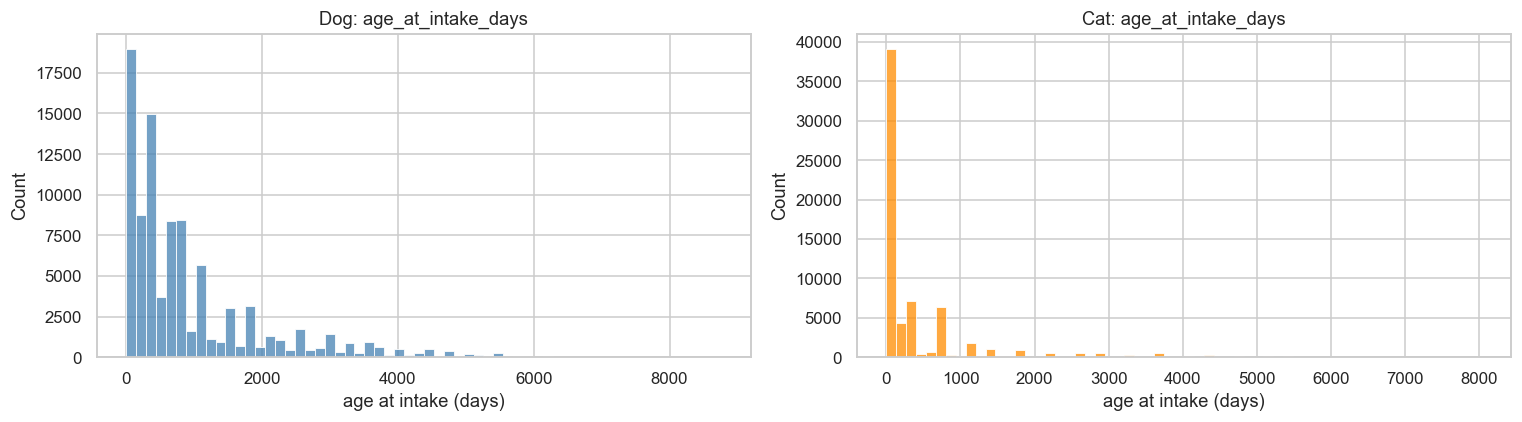

               Dog       Cat
count     93376.00  67574.00
mean        952.23    489.14
std        1104.29    937.76
min           0.00      0.00
25%         201.00     31.00
50%         620.00     83.00
75%        1118.00    440.00
max        8766.00   8036.00
skewness      1.93      3.21

Dog: skewness = 1.93  ->  STRONG right-skew -> consider log-transform or bucket
Cat: skewness = 3.21  ->  STRONG right-skew -> consider log-transform or bucket


In [204]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    sns.histplot(frame['age_at_intake_days'].dropna(), bins=60, color=color, ax=ax)
    ax.set_title(f'{sp}: age_at_intake_days')
    ax.set_xlabel('age at intake (days)')
fig.tight_layout(); plt.show()

desc = pd.concat({'Dog': dogs['age_at_intake_days'].describe(),
                  'Cat': cats['age_at_intake_days'].describe()}, axis=1)
desc.loc['skewness'] = [dogs['age_at_intake_days'].skew(), cats['age_at_intake_days'].skew()]
print(desc.round(2))
print()
for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    sk = frame['age_at_intake_days'].skew()
    flag = 'STRONG right-skew -> consider log-transform or bucket' if sk > 1 else 'mild skew'
    print(f'{sp}: skewness = {sk:.2f}  ->  {flag}')

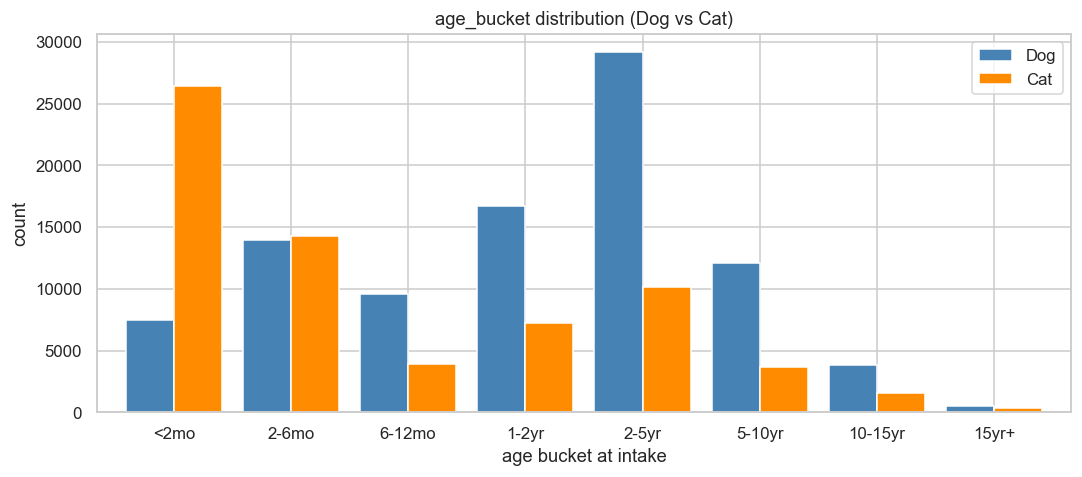

In [205]:
# --- age_bucket: bin age_at_intake_days (display-only) ---
AGE_BINS   = [0, 60, 180, 365, 730, 1825, 3650, 5475, np.inf]
AGE_LABELS = ['<2mo', '2-6mo', '6-12mo', '1-2yr', '2-5yr', '5-10yr', '10-15yr', '15yr+']
df_adopt['age_bucket'] = pd.cut(
    df_adopt['age_at_intake_days'], bins=AGE_BINS, labels=AGE_LABELS, right=False
)
df_adopt['age_bucket'] = df_adopt['age_bucket'].cat.set_categories(AGE_LABELS, ordered=True)

# bar chart of the age_bucket distribution (Dog vs Cat)
_ab = (df_adopt.groupby(['age_bucket', 'animal_type'], observed=True).size()
       .unstack(fill_value=0).reindex(AGE_LABELS))
_ab = _ab[[c for c in ['Dog', 'Cat'] if c in _ab.columns]]
ax = _ab.plot(kind='bar', figsize=(10, 4.5), width=0.82,
              color={'Dog': DOG_COLOR, 'Cat': CAT_COLOR})
ax.set_xlabel('age bucket at intake'); ax.set_ylabel('count')
ax.set_title('age_bucket distribution (Dog vs Cat)')
ax.legend(title='')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Observations (fill in yourself):**

- Both distributions are right-skewed — for modeling, would you log-transform age, bucket it, or keep it raw?
  > I think if we re going to use logistic regression, we shoul log(age) to preserve the feature, and I'm also planning to use XGBoost, for this don't need to further process age. 
- Do dogs and cats enter at noticeably different ages? What might explain it?
  > Cats entered age are significantly younger than dogs, indicate lots kittens are taken to shelter or even born in shelter. 


### 2.2 Categorical distributions: `sex`, `intake_reason`, `intake_health_condition`, `is_mix`

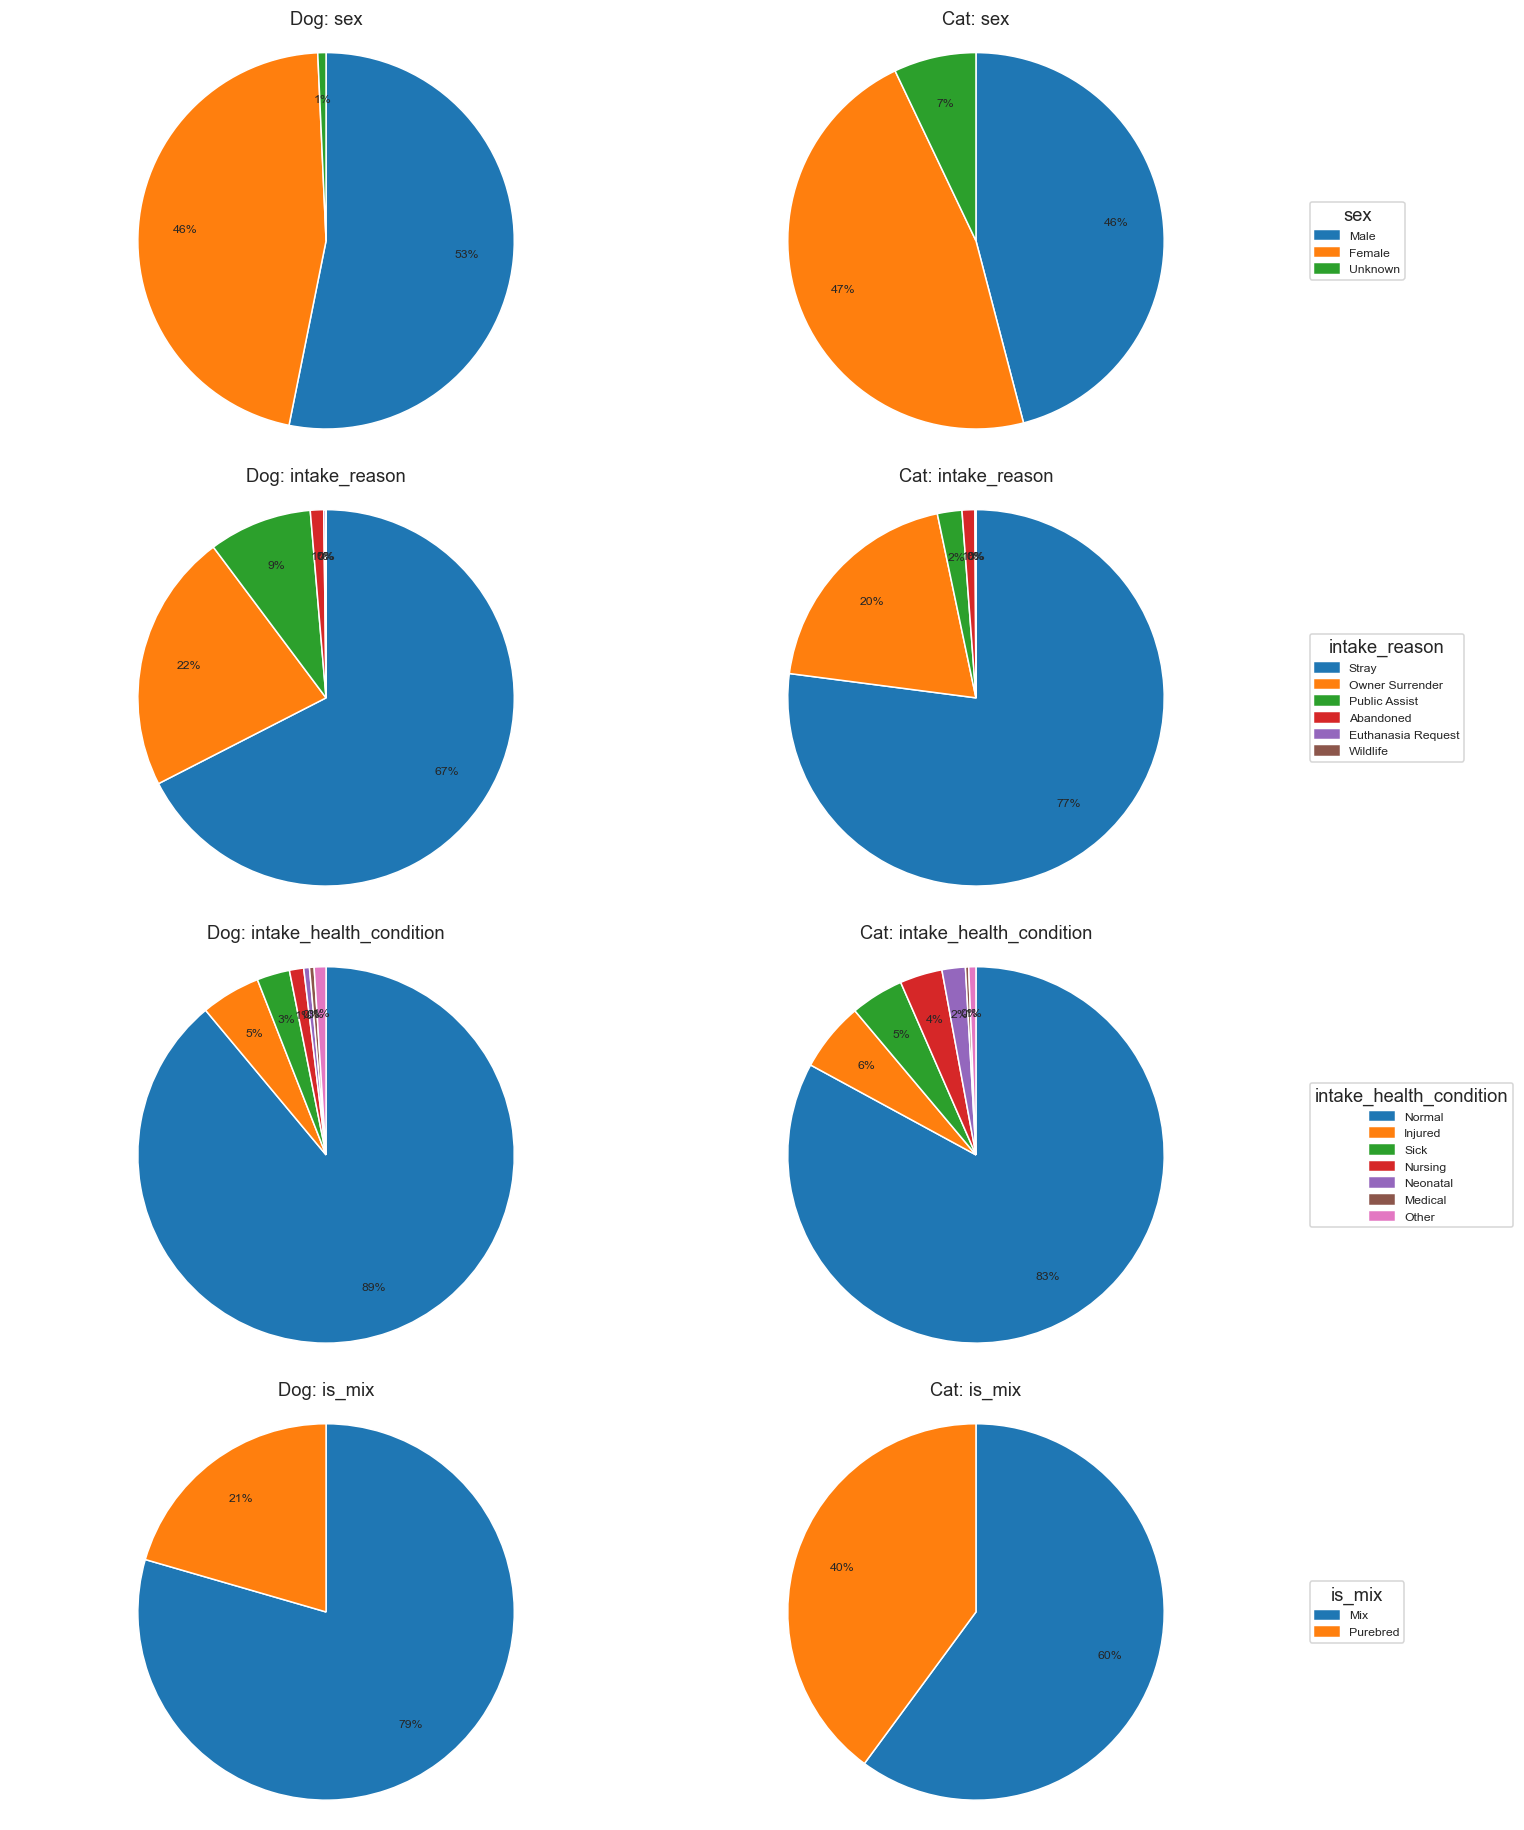

In [206]:
import matplotlib.patheffects as path_effects

cat_feats = ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']
TOP_N = 6
fig, axes = plt.subplots(len(cat_feats), 2, figsize=(14, 4.2 * len(cat_feats)))

def _autopct(p):
    return f'{p:.0f}%' if p >= 3 else ''   # hide tiny slivers so labels don't overlap

for r, col in enumerate(cat_feats):
    # Determine category order ONCE across both species, keep top-N, lump rest into 'Other'.
    full_order = df_adopt[col].value_counts().index.tolist()
    keep = full_order[:TOP_N]
    has_other = len(full_order) > TOP_N
    cats_for_legend = keep + (['Other'] if has_other else [])
    cmap = plt.cm.tab20 if len(cats_for_legend) > 10 else plt.cm.tab10
    color_map = {cat: cmap(i % cmap.N) for i, cat in enumerate(cats_for_legend)}
    for c, (sp, frame) in enumerate([('Dog', dogs), ('Cat', cats)]):
        vc = frame[col].value_counts()
        sizes, slice_cats = [], []
        for cat in keep:
            sizes.append(vc.get(cat, 0)); slice_cats.append(cat)
        if has_other:
            sizes.append(vc.drop(labels=[k for k in keep if k in vc.index]).sum()); slice_cats.append('Other')
        colors = [color_map[cat] for cat in slice_cats]
        ax = axes[r, c]
        wedges, _, autotexts = ax.pie(
            sizes, colors=colors, autopct=_autopct, pctdistance=0.72,
            startangle=90, counterclock=False, normalize=True,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1})
        # Make the % labels clearly readable on ANY slice color: bold white + black outline.
        for t in autotexts:
            t.set_fontsize(11); t.set_fontweight('bold'); t.set_color('white')
            t.set_path_effects([path_effects.withStroke(linewidth=2.2, foreground='black')])
        ax.set_title(f'{sp}: {col}')
        ax.axis('equal')
    legend_labels = [str(LABEL_MAP.get(col, {}).get(cat, cat)) for cat in cats_for_legend]
    legend_handles = [plt.matplotlib.patches.Patch(color=color_map[cat]) for cat in cats_for_legend]
    axes[r, 1].legend(legend_handles, legend_labels, title=col,
                      loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
fig.tight_layout(); plt.show()

**Observations (fill in yourself):**

- Which categorical features look most *different* between dogs and cats?
  > More dogs are coming from public assist than cats. More cats' gender are unknown. More purebred cats than purebred dogs
- Does `intake_health_condition` have rare categories you may want to group before modeling?
  > I want to group: injured, Sick, medical

### 2.3 `primary_breed` — TOP 15 per species (separate plots; breeds do **not** overlap)

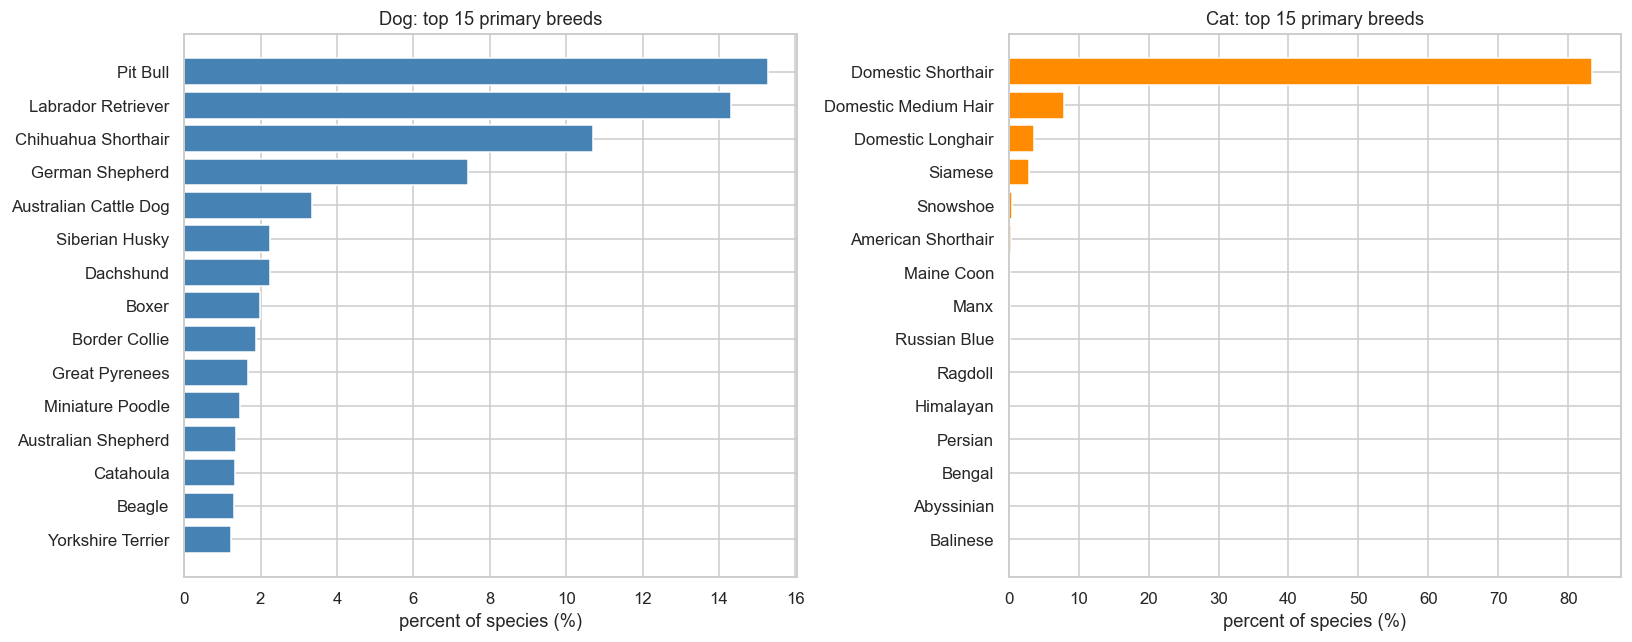

Dog: 211 unique breeds; 100 are rare (<50 rows).
Cat: 44 unique breeds; 33 are rare (<50 rows).


In [207]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (sp, frame, color) in zip(axes, [('Dog', dogs, DOG_COLOR), ('Cat', cats, CAT_COLOR)]):
    pct = frame['primary_breed'].value_counts(normalize=True).head(15) * 100
    ax.barh(pct.index[::-1], pct.values[::-1], color=color)
    ax.set_title(f'{sp}: top 15 primary breeds')
    ax.set_xlabel('percent of species (%)')
fig.tight_layout(); plt.show()

for sp, frame in [('Dog', dogs), ('Cat', cats)]:
    vc = frame['primary_breed'].value_counts()
    rare = int((vc < 50).sum())
    print(f'{sp}: {frame["primary_breed"].nunique()} unique breeds; '
          f'{rare} are rare (<50 rows).')

**Observations (fill in yourself):**

- How concentrated is each species? (e.g. what share of cats is just Domestic Shorthair?)
  > for cats around 85% are domestic short hair
- With this many rare breeds, would you bucket them into 'Other' or keep a top-N + is_mix encoding?
  > Dog: 211 unique breeds; 100 are rare (<50 rows). I'm not sure how should I handle them

In [ ]:
# --- color_group: collapse ~58 raw colors into families/patterns (display-only) ---
COLOR_BASE = {
    'Black': 'Black', 'White': 'White',
    'Brown': 'Brown', 'Chocolate': 'Brown', 'Sable': 'Brown', 'Liver': 'Brown',
    'Agouti': 'Brown', 'Ruddy': 'Brown',
    'Tan': 'Tan', 'Fawn': 'Tan', 'Buff': 'Tan', 'Apricot': 'Tan', 'Gold': 'Tan', 'Yellow': 'Tan',
    'Blue': 'Blue/Gray', 'Gray': 'Blue/Gray', 'Silver': 'Blue/Gray', 'Lilac': 'Blue/Gray',
    'Red': 'Red/Orange', 'Orange': 'Red/Orange',
    'Cream': 'Cream',
}
def to_color_group(c):
    if pd.isna(c):                                              return 'Unknown'
    if 'Tabby' in c:                                            return 'Tabby'
    if 'Calico' in c:                                           return 'Calico'
    if 'Tortie' in c or 'Torbie' in c:                          return 'Tortie'
    if 'Point' in c:                                            return 'Point'
    if 'Brindle' in c:                                          return 'Brindle'
    if 'Merle' in c:                                            return 'Merle'
    if 'Tricolor' in c:                                         return 'Tricolor'
    return COLOR_BASE.get(c.split()[0], 'Other')

# apply the same grouping to BOTH colors (secondary NaN -> 'single color')
df_adopt['color_group']           = df_adopt['primary_color'].map(to_color_group)
df_adopt['secondary_color_group'] = (df_adopt['secondary_color'].map(to_color_group)
                                      .replace('Unknown', 'Single color'))  # NaN = no 2nd color

# Cats have very few of these warm/solid colors -> fold into 'Other' (dogs unaffected)
CAT_MERGE_TO_OTHER = ['Tan', 'Cream', 'Brown', 'Red/Orange']
_is_cat = df_adopt['animal_type'].eq('Cat')
df_adopt.loc[_is_cat & df_adopt['color_group'].isin(CAT_MERGE_TO_OTHER), 'color_group'] = 'Other'

print('\ncolor_group counts (primary):')
print(df_adopt['color_group'].value_counts())
print('\nsecondary_color_group counts:')
print(df_adopt['secondary_color_group'].value_counts())


color_group counts (primary):
color_group
Black         39647
Tabby         30672
White         20822
Brown         16371
Tan           14688
Blue/Gray     10223
Tortie         6106
Brindle        5155
Red/Orange     3963
Tricolor       3884
Calico         3283
Point          2632
Cream          1395
Merle          1235
Other           904
Name: count, dtype: int64

secondary_color_group counts:
secondary_color_group
Single color    74524
White           53057
Black           10404
Tan              8097
Brown            7522
Blue/Gray        2146
Tabby            1328
Tricolor         1219
Brindle           972
Red/Orange        836
Cream             532
Merle             202
Calico             59
Point              40
Tortie             39
Other               3
Name: count, dtype: int64


## 3. Bivariate Analysis — features vs `is_adopted`
_Dogs and cats computed separately. Red dashed line = that species' overall adoption rate._

### 3.0 Reusable helper

In [208]:
def plot_adoption_rate_by(col, data, top_n=None, min_count=30,
                          ax=None, title=None, color='steelblue', sort='rate'):
    """Horizontal bar chart of adoption rate per category of `col` within `data`.

    - Drops categories with fewer than `min_count` rows.
    - If `top_n` is given, keeps the `top_n` most frequent categories.
    - Draws a red dashed line at this data's overall is_adopted mean.
    - Annotates each bar with its sample size (n=...).
    - sort='rate' orders bars by adoption rate; sort='index' keeps category order
      (use 'index' for ordered buckets like age_bucket).
    """
    g = data.groupby(col, observed=True)[TARGET].agg(rate='mean', n='count')
    g = g[g['n'] >= min_count]
    if top_n is not None:
        g = g.nlargest(top_n, 'n')
    g = g.sort_values('rate') if sort == 'rate' else g.sort_index()
    if ax is None:
        _, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(g))))
    labels = [str(LABEL_MAP.get(col, {}).get(i, i)) for i in g.index]
    ax.barh(labels, g['rate'].values, color=color)
    overall = data[TARGET].mean()
    ax.axvline(overall, color='red', ls='--', lw=1.5, label=f'overall {overall:.2f}')
    for y, (rate, n) in enumerate(zip(g['rate'], g['n'])):
        ax.text(min(rate + 0.01, 0.99), y, f'n={int(n)}', va='center', fontsize=8)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel('adoption rate')
    ax.set_title(title or f'adoption rate by {col}')
    ax.legend(loc='lower right', fontsize=8)
    return ax

### 3.1 Adoption rate by each categorical feature (Dog | Cat)

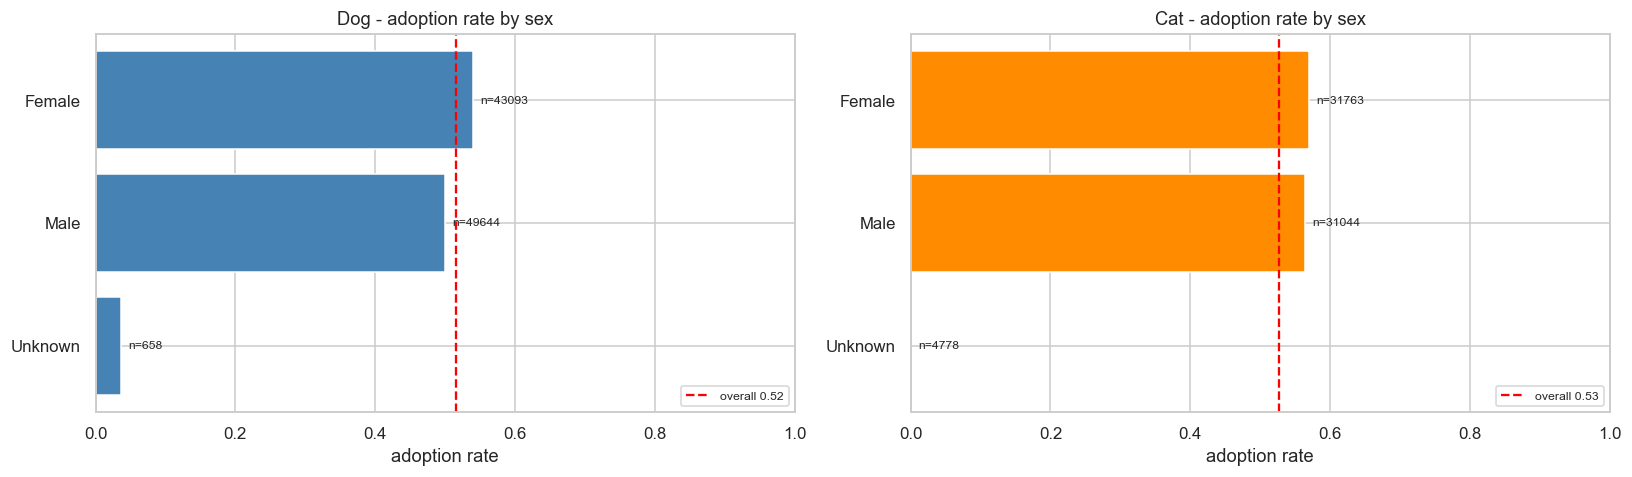

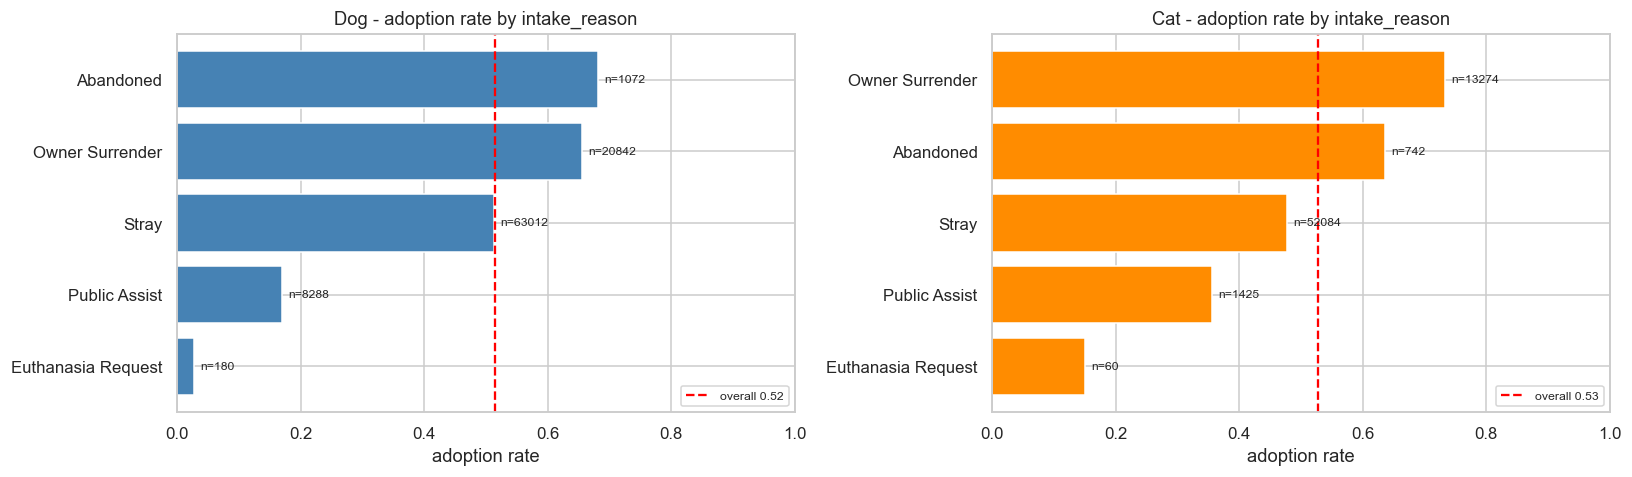

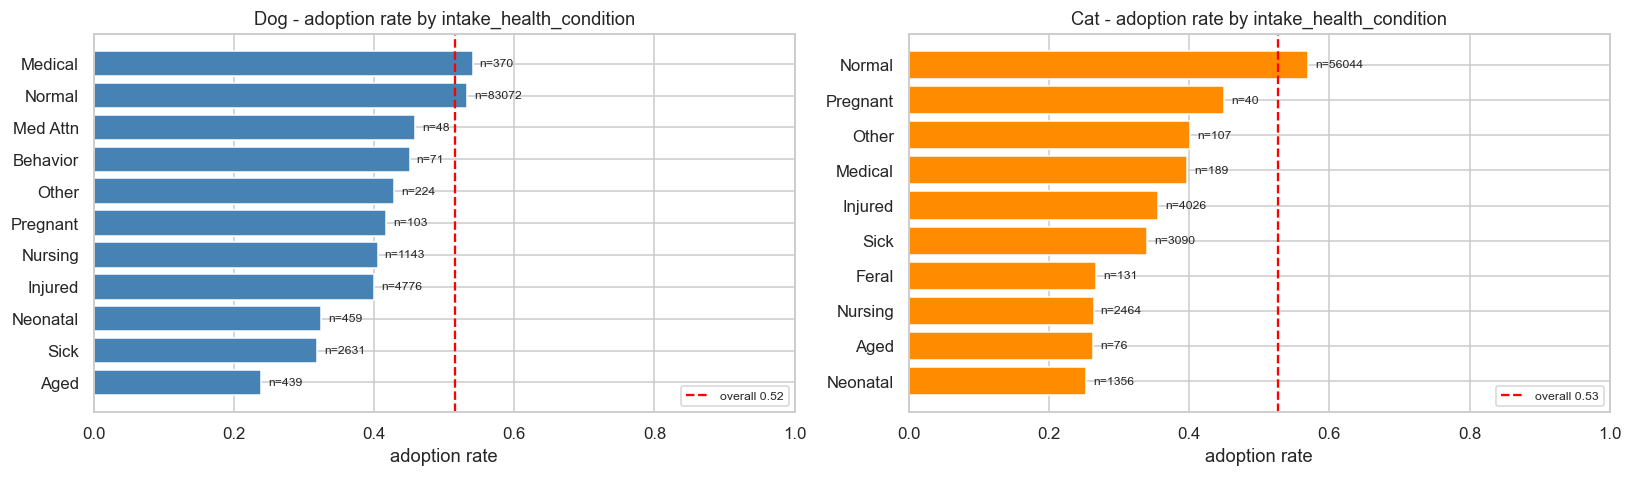

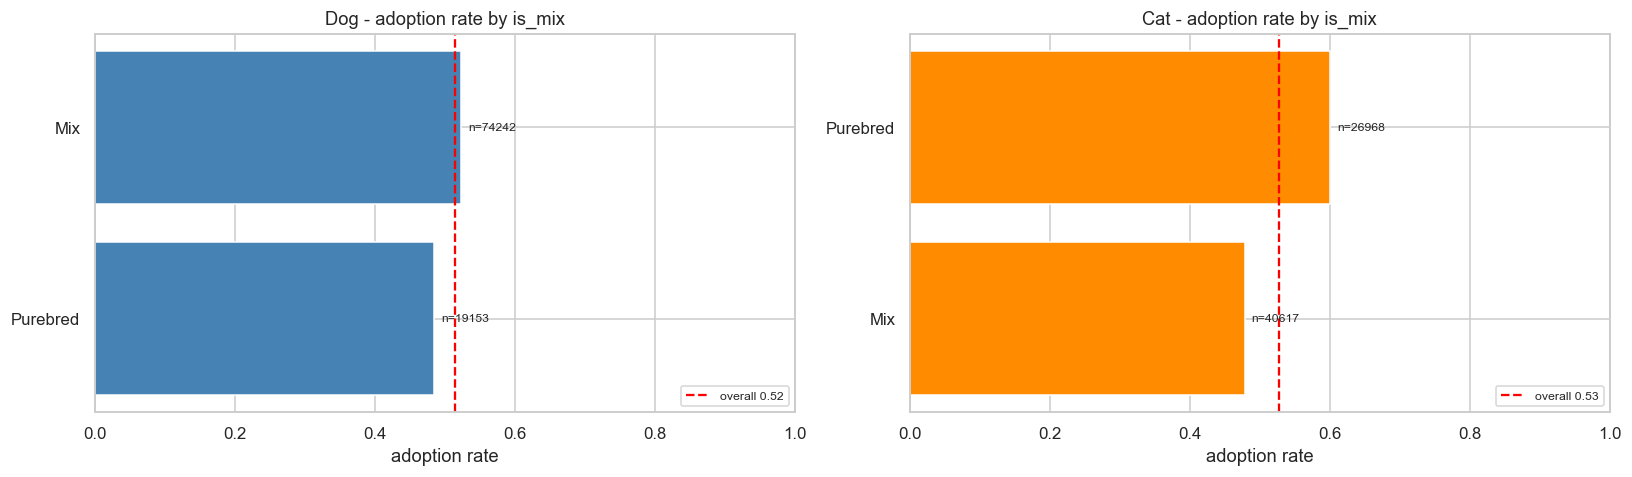

In [209]:
for col in ['sex', 'intake_reason', 'intake_health_condition', 'is_mix']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    plot_adoption_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - adoption rate by {col}', color=DOG_COLOR)
    plot_adoption_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - adoption rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

### 3.2 Adoption rate by breed (top 15 by volume, min 100 rows)

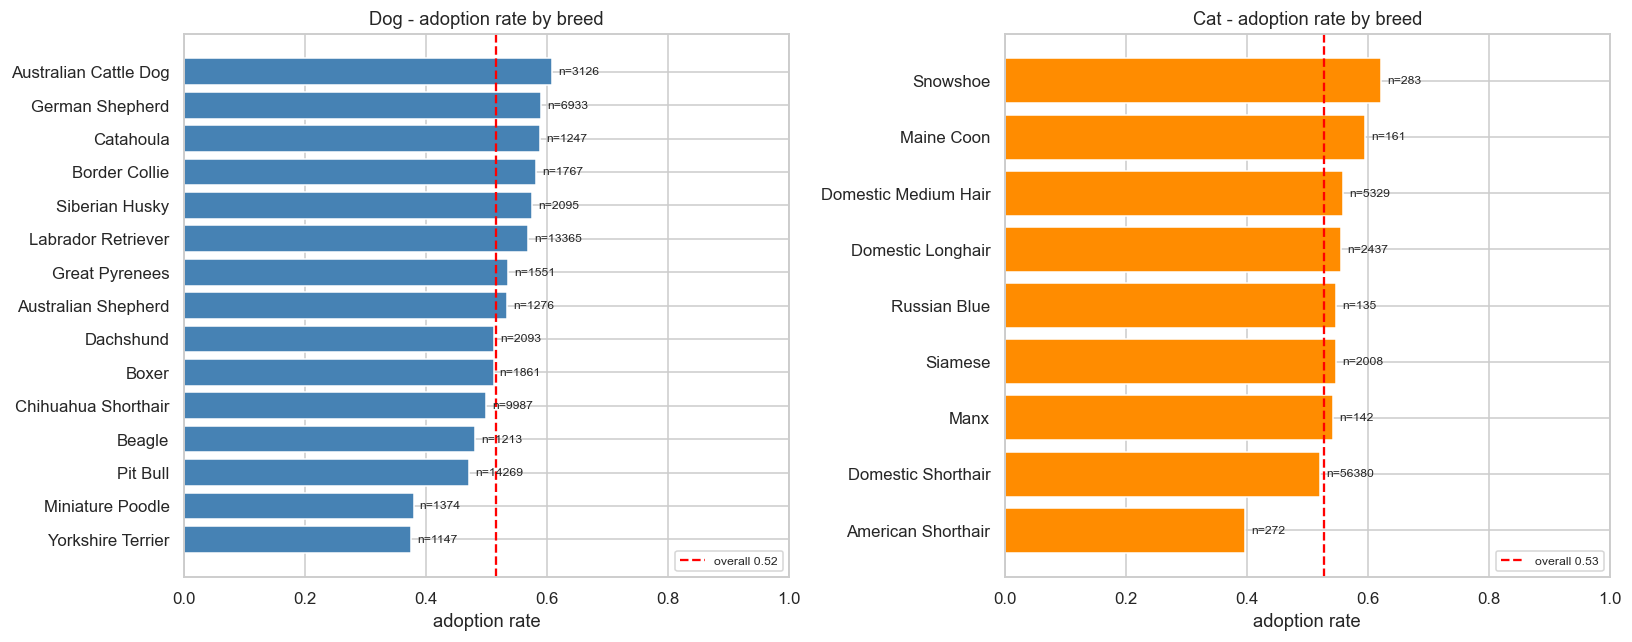

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_adoption_rate_by('primary_breed', dogs, top_n=15, min_count=100, ax=axes[0],
                      title='Dog - adoption rate by breed', color=DOG_COLOR)
plot_adoption_rate_by('primary_breed', cats, top_n=15, min_count=100, ax=axes[1],
                      title='Cat - adoption rate by breed', color=CAT_COLOR)
fig.tight_layout(); plt.show()

### 3.3 Adoption rate by age bucket (Dog | Cat)

KeyError: 'age_bucket'

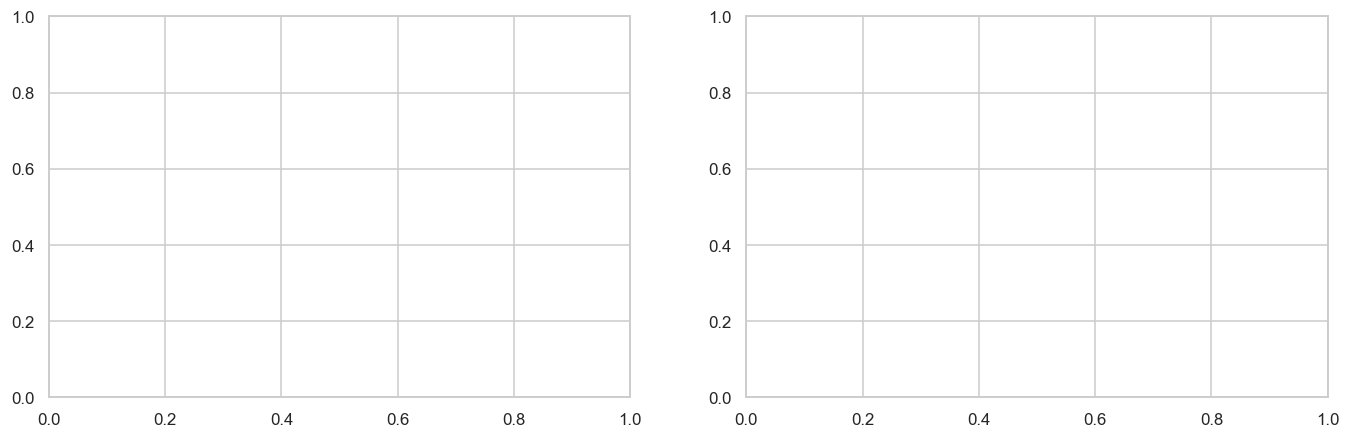

In [211]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_adoption_rate_by('age_bucket', dogs, ax=axes[0], min_count=30, sort='index',
                      title='Dog - adoption rate by age bucket', color=DOG_COLOR)
plot_adoption_rate_by('age_bucket', cats, ax=axes[1], min_count=30, sort='index',
                      title='Cat - adoption rate by age bucket', color=CAT_COLOR)
fig.tight_layout(); plt.show()

**Observations (fill in yourself):**

- Which single feature separates adopted vs not-adopted the most for *dogs*? For *cats*?
  > 
- Do any categories sit far from the red overall-mean line? Are their sample sizes large enough to trust?
  > 
- How does adoption rate move across age buckets for each species - same direction or opposite?
  > 

### 3.5 Adoption rate by grouped color (Dog | Cat)
The grouped view (defined in 1.4) is far more readable than the 50+ raw colors above. Shown for both `color_group` (primary) and `secondary_color_group` — for the latter, `single color` means the animal has no secondary color.

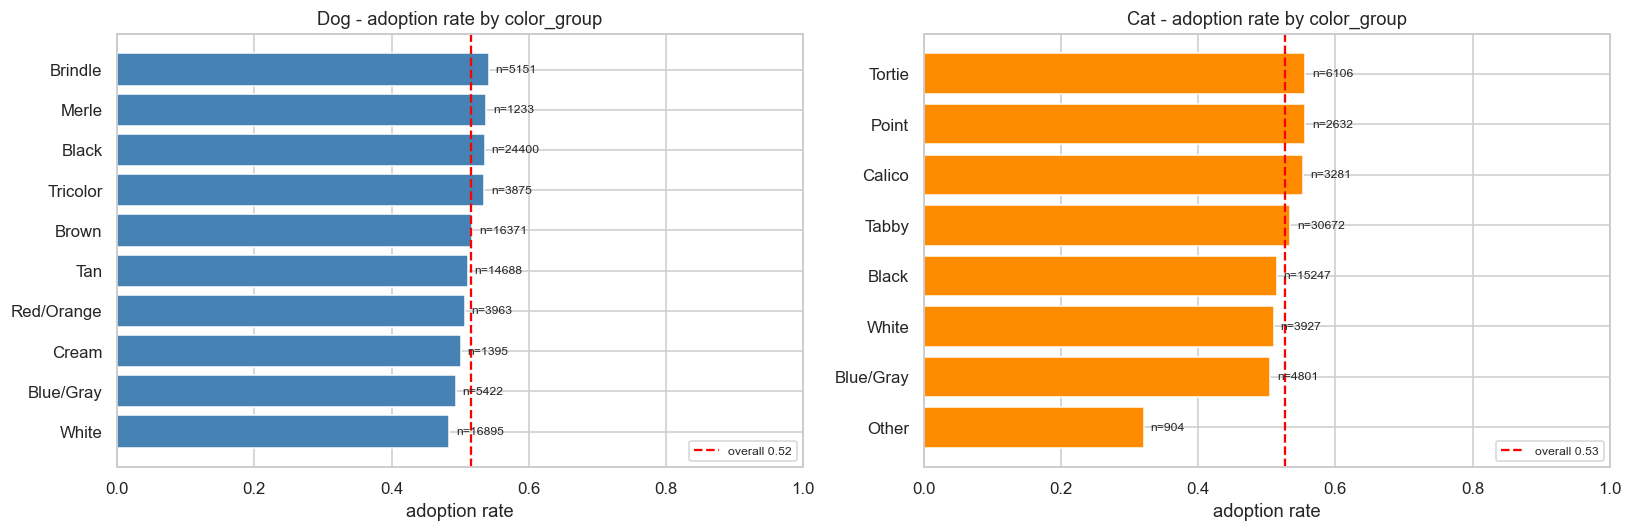

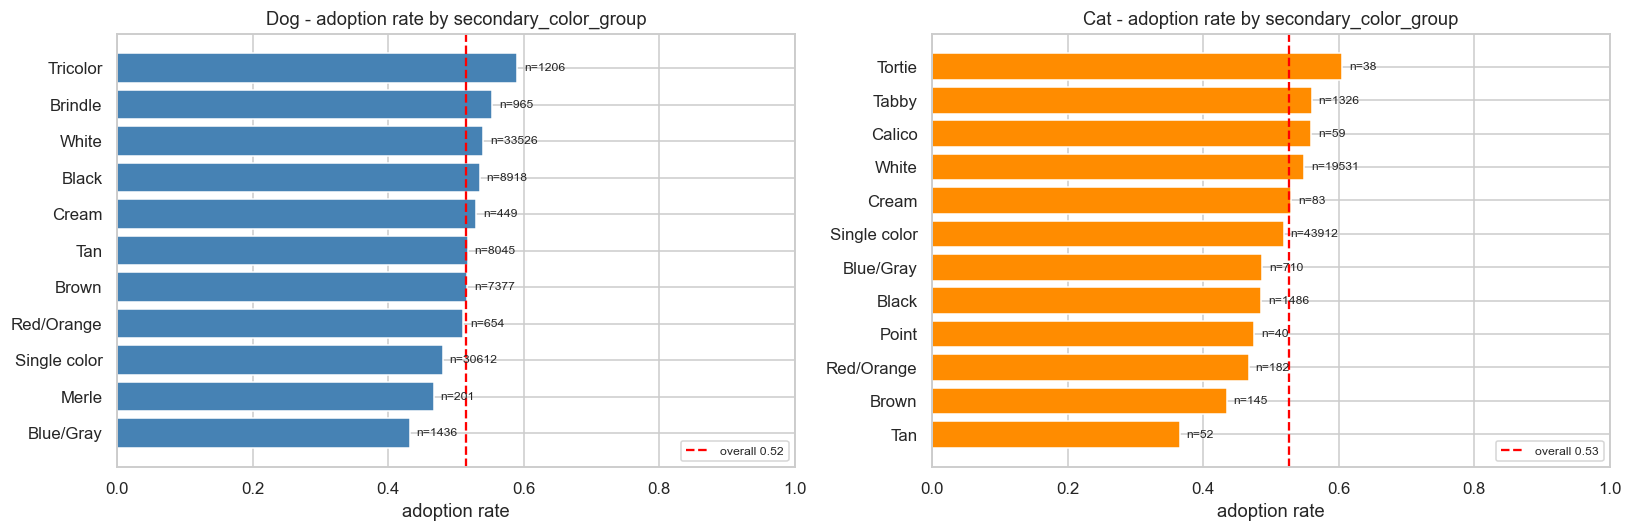

In [ ]:
for col in ['color_group', 'secondary_color_group']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_adoption_rate_by(col, dogs, ax=axes[0], min_count=30,
                          title=f'Dog - adoption rate by {col}', color=DOG_COLOR)
    plot_adoption_rate_by(col, cats, ax=axes[1], min_count=30,
                          title=f'Cat - adoption rate by {col}', color=CAT_COLOR)
    fig.tight_layout(); plt.show()

**Observations (fill in yourself):**

- Which color groups land furthest above/below the red overall-mean line for each species?
  > 
- Do any patterns read as species-specific (e.g. Tabby/Tortie for cats, Brindle/Merle for dogs)?
  > 

## 4. Multivariate / Interaction Analysis

### 4.1 Headline: dog vs cat adoption rate by age bucket (one chart)
This is the key reason the two species must not be pooled.

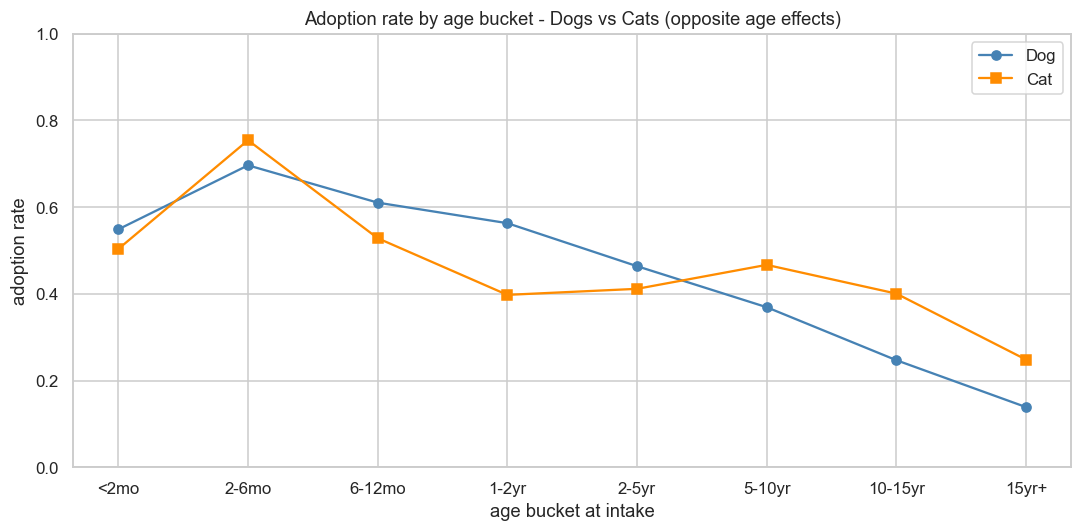

              Dog    Cat
age_bucket              
<2mo        0.549  0.504
2-6mo       0.697  0.754
6-12mo      0.611  0.528
1-2yr       0.563  0.398
2-5yr       0.464  0.412
5-10yr      0.369  0.467
10-15yr     0.247  0.401
15yr+       0.139  0.249


In [ ]:
dog_rate = dogs.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)
cat_rate = cats.groupby('age_bucket', observed=True)[TARGET].mean().reindex(AGE_LABELS)

plt.figure(figsize=(10, 5))
plt.plot(AGE_LABELS, dog_rate.values, marker='o', color=DOG_COLOR, label='Dog')
plt.plot(AGE_LABELS, cat_rate.values, marker='s', color=CAT_COLOR, label='Cat')
plt.ylabel('adoption rate'); plt.xlabel('age bucket at intake')
plt.title('Adoption rate by age bucket - Dogs vs Cats (opposite age effects)')
plt.ylim(0, 1); plt.legend(); plt.tight_layout(); plt.show()

print(pd.DataFrame({'Dog': dog_rate, 'Cat': cat_rate}).round(3))

### 4.2 Correlation heatmaps — computed separately per species
Encoded numeric view: `is_mix`, `is_fixed` (previously spayed/neutered), `health_normal` (intake condition == Normal), `age_days`, and the target.

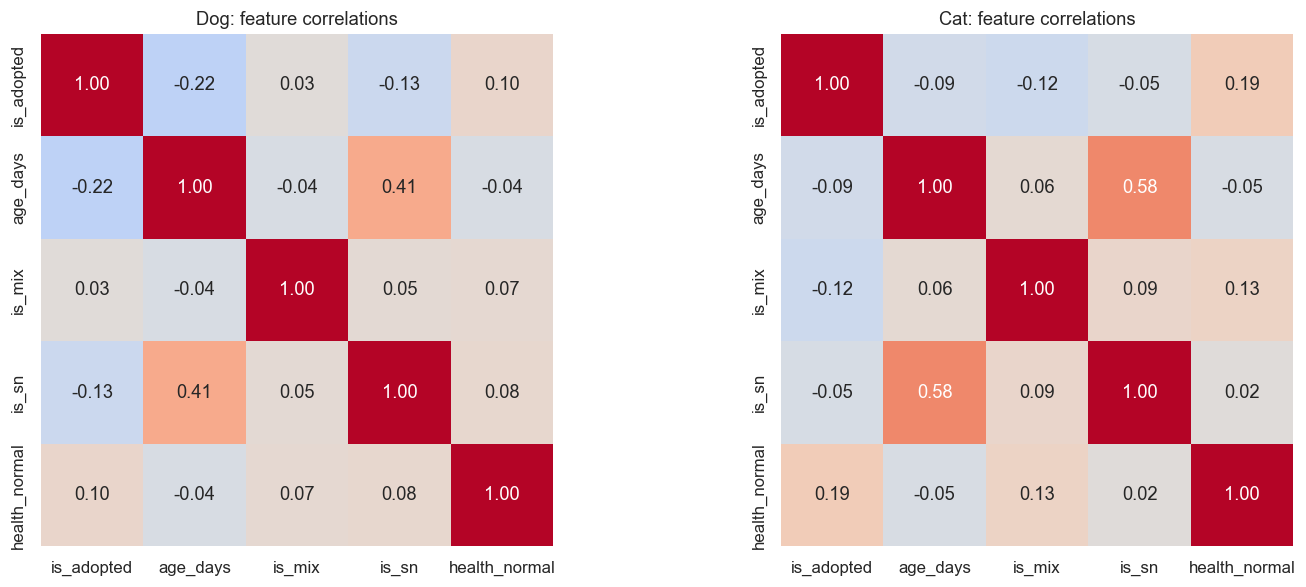

In [ ]:
def encode_for_corr(frame):
    return pd.DataFrame({
        'is_adopted':    frame[TARGET],
        'age_days':      frame['age_at_intake_days'],
        'is_mix':        frame['is_mix'],
        'is_sn':      frame['is_previously_spayed_neutered'],
        'health_normal': (frame['intake_health_condition'] == 'Normal').astype(int),
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    corr = encode_for_corr(frame).corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, cbar=False, ax=ax)
    ax.set_title(f'{sp}: feature correlations')
fig.tight_layout(); plt.show()

**Observations (fill in yourself):**

- Which feature has the strongest (signed) correlation with adoption for dogs? For cats? 
> age_at_intake_days looks like the strongest feature in dogs with -0.22 and health_normal in cats with 0.19. But both are not really strong 
- Does `age_days` flip sign between the two heatmaps, matching the headline chart?
  > no
- Are any features strongly correlated with *each other* (redundancy to watch in modeling)?
  > is_sn is strongly correlated with age_days

### 4.3 Color × sex association (Dog | Cat)
Both are categorical, so the "correlation matrix" is built by one-hot encoding `color_group` (grouped `primary_color`) and `sex`, then correlating each color group against each sex (point-biserial on 0/1 dummies). Watch the cats: tortie & calico coats are almost always **female** (the coat-color gene is X-linked).

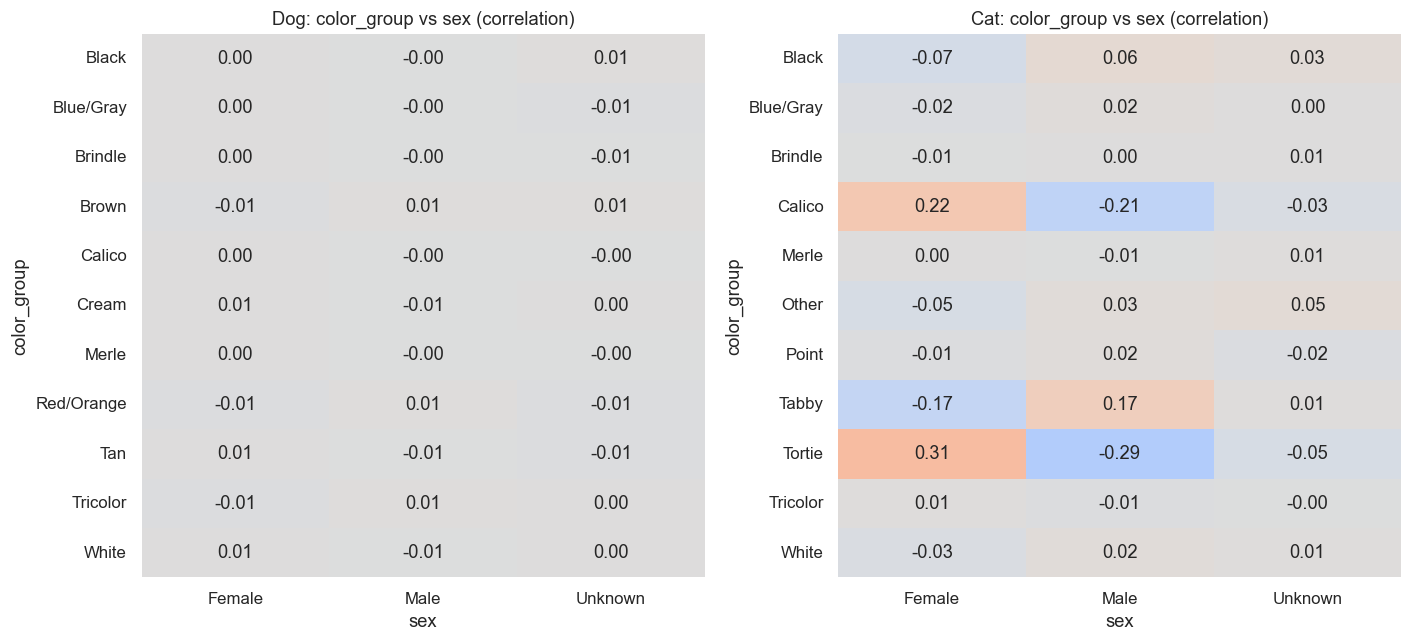

In [ ]:
def color_sex_corr(frame, color_col='color_group'):
    """Correlation of each color-group indicator (rows) with each sex indicator (cols)."""
    cd = pd.get_dummies(frame[color_col]).astype(int)
    sd = pd.get_dummies(frame['sex']).astype(int)
    return pd.DataFrame(
        {s: cd.apply(lambda col: np.corrcoef(col, sd[s])[0, 1]) for s in sd.columns}
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (sp, frame) in zip(axes, [('Dog', dogs), ('Cat', cats)]):
    M = color_sex_corr(frame)
    sns.heatmap(M, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                vmin=-1, vmax=1, cbar=False, ax=ax)
    ax.set_title(f'{sp}: color_group vs sex (correlation)')
    ax.set_xlabel('sex'); ax.set_ylabel('color_group')
fig.tight_layout(); plt.show()

**Observations (fill in yourself):**

- For cats, how strong is the tortie/calico -> female association? Any male torties at all?
  > 
- Do dogs show any color-sex link, or is the matrix essentially flat (no association)?
  > 

## 5. Temporal Analysis
_Uses the full `df` (all outcomes) for intake volume; `df_adopt` for adoption rate._

**2013 and 2025 are partial years** - exclude them when reading year-over-year trends.

### 5.1 Intake volume per year

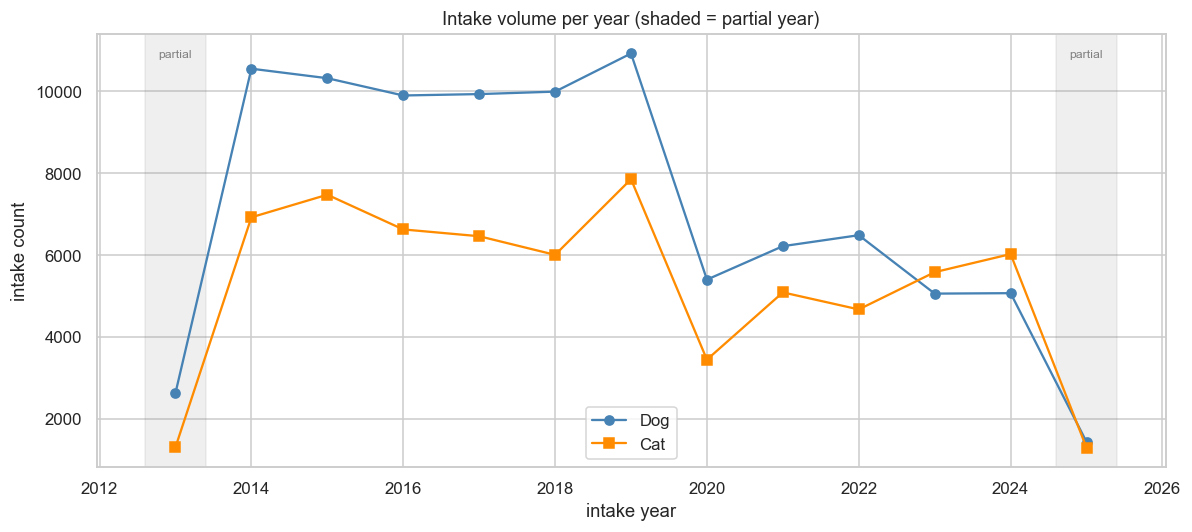

In [ ]:
yearly = df.groupby(['intake_year', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yearly.index, yearly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yearly.index, yearly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.text(2013, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.text(2025, plt.ylim()[1]*0.95, 'partial', ha='center', fontsize=8, color='grey')
plt.ylabel('intake count'); plt.xlabel('intake year')
plt.title('Intake volume per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Seasonality: intake volume per month (kitten-season check)
Expect **cats to spike May-Sep**.

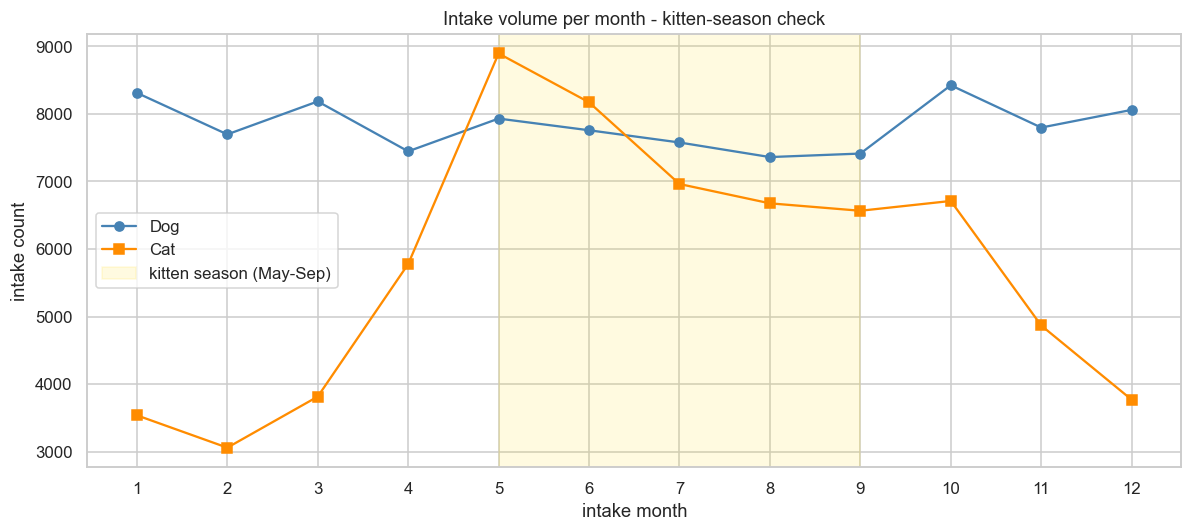

In [ ]:
monthly = df.groupby(['intake_month', 'animal_type']).size().unstack()
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(monthly.index, monthly['Cat'], marker='s', color=CAT_COLOR, label='Cat')
plt.axvspan(5, 9, color='gold', alpha=0.12, label='kitten season (May-Sep)')
plt.xticks(range(1, 13))
plt.ylabel('intake count'); plt.xlabel('intake month')
plt.title('Intake volume per month - kitten-season check')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Adoption rate per year (data-drift check)
Overall adoption rate has risen over time (~42% in 2013 to ~66% in 2024).

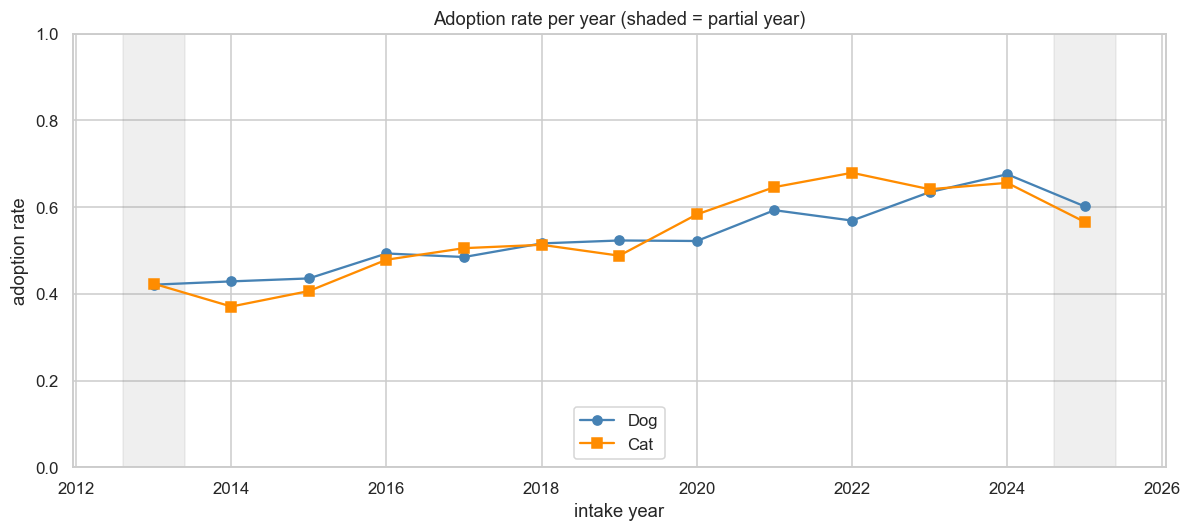

animal_type    Cat    Dog
intake_year              
2013         0.424  0.421
2014         0.371  0.429
2015         0.407  0.436
2016         0.479  0.493
2017         0.506  0.485
2018         0.513  0.517
2019         0.488  0.523
2020         0.583  0.522
2021         0.646  0.593
2022         0.679  0.569
2023         0.641  0.635
2024         0.656  0.676
2025         0.566  0.602


In [ ]:
yr_rate = df_adopt.groupby(['intake_year', 'animal_type'])[TARGET].mean().unstack()
plt.figure(figsize=(11, 5))
plt.plot(yr_rate.index, yr_rate['Dog'], marker='o', color=DOG_COLOR, label='Dog')
plt.plot(yr_rate.index, yr_rate['Cat'], marker='s', color=CAT_COLOR, label='Cat')
for yr in (2013, 2025):
    plt.axvspan(yr - 0.4, yr + 0.4, color='grey', alpha=0.12)
plt.ylabel('adoption rate'); plt.xlabel('intake year'); plt.ylim(0, 1)
plt.title('Adoption rate per year (shaded = partial year)')
plt.legend(); plt.tight_layout(); plt.show()

print(yr_rate.round(3))

**Observations (fill in yourself):**

- After ignoring 2013 and 2025, is the upward adoption-rate drift real for both species?
  > 
- Does the cat intake spike land in May-Sep as expected? How big is it vs dogs?
  > 
- Could the time drift hurt a model trained on old years and tested on recent ones?
  > 

## 6. EDA Summary (fill-in-the-blank)

### Scope & data quality
- Rows analyzed: **dogs = 93962**, **cats = 68803** (from `df_adopt`).
- Non-dog/cat rows dropped: **1,785**. Non-modelable / missing-outcome rows.
- Known data-quality notes: unknown `sex` -> `is_previously_spayed_neutered` is NaN; some ages are NaN; 2013 & 2025 are partial years.

### Top predictive features (per species)
- **Dogs:** the features that separate adopted vs not most are age, ____, ____.
- **Cats:** the features that separate adopted vs not most are age, ____, ____.

### The dog-vs-cat age contrast (headline)
- For **dogs**, adoption rate falls as age increases.
- For **cats**, adoption rate falls as age increases.
- Conclusion: 

### Temporal / seasonal findings
- Intake volume trend (ignoring partial years): ____.
- Kitten-season spike for cats in May-Sep: **present** - magnitude strong.
- Adoption-rate drift over time: generally increased (and its modeling implication: ____).

### To-do before modeling
- [ ] Decide age handling (log) per species.
- [ ] Decide breed handling (top-N + Other, or is_mix only) per species. no idea, please suggest
- [ ] Group rare categories in `intake_health_condition` / `intake_reason`.
- [ ] Handle NaNs in `is_previously_spayed_neutered` and `age_at_intake_days`.
- [ ] Confirm NO leakage columns leak into features: `outcome_*`, `length_of_stay_days`, `is_RTO/transfer/euthanasia`.
- [ ] Consider a time-based train/test split given the adoption-rate drift.
